In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import plotly.express as px
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.model_selection import train_test_split

In [13]:
raw_df = pd.read_csv("C:/dev/sklearn_freeCodeAcademy/full_course_Aakash_N_S/weatherAUS.csv", encoding="utf-8-sig", low_memory=False)

In [14]:
raw_df.head(3)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No


In [15]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [17]:
raw_df.dropna(subset=["RainToday", "RainTomorrow"], inplace=True)

In [19]:
raw_df.info()

<class 'pandas.DataFrame'>
Index: 140787 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           140787 non-null  str    
 1   Location       140787 non-null  str    
 2   MinTemp        140319 non-null  float64
 3   MaxTemp        140480 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81093 non-null   float64
 6   Sunshine       73982 non-null   float64
 7   WindGustDir    131624 non-null  str    
 8   WindGustSpeed  131682 non-null  float64
 9   WindDir9am     131127 non-null  str    
 10  WindDir3pm     137117 non-null  str    
 11  WindSpeed9am   139732 non-null  float64
 12  WindSpeed3pm   138256 non-null  float64
 13  Humidity9am    139270 non-null  float64
 14  Humidity3pm    137286 non-null  float64
 15  Pressure9am    127044 non-null  float64
 16  Pressure3pm    127018 non-null  float64
 17  Cloud9am       88162 non-null   float64
 18  

In [21]:
sns.set_style("darkgrid")
plt.rcParams["font.size"] = 14
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["figure.facecolor"] = '#00000000'

px.histogram(raw_df, x="Location", title="Location vs. Rainy Days", color="RainToday")

In [22]:
raw_df.Location.unique()

<StringArray>
[          'Albury',    'BadgerysCreek',            'Cobar',
     'CoffsHarbour',            'Moree',        'Newcastle',
        'NorahHead',    'NorfolkIsland',          'Penrith',
         'Richmond',           'Sydney',    'SydneyAirport',
       'WaggaWagga',      'Williamtown',       'Wollongong',
         'Canberra',      'Tuggeranong',      'MountGinini',
         'Ballarat',          'Bendigo',             'Sale',
 'MelbourneAirport',        'Melbourne',          'Mildura',
             'Nhil',         'Portland',         'Watsonia',
         'Dartmoor',         'Brisbane',           'Cairns',
        'GoldCoast',       'Townsville',         'Adelaide',
     'MountGambier',        'Nuriootpa',          'Woomera',
           'Albany',      'Witchcliffe',       'PearceRAAF',
     'PerthAirport',            'Perth',       'SalmonGums',
          'Walpole',           'Hobart',       'Launceston',
     'AliceSprings',           'Darwin',        'Katherine',
          

In [23]:
px.histogram(raw_df,
             x="Temp3pm",
             title="Temperature at 3p.m vs. Rain Tomorrow",
             color="RainTomorrow")

In [26]:
px.histogram(raw_df,
             x="RainTomorrow",
             title="Rain Tomorrow vs. Rain Today",
             color="RainToday")

In [24]:
px.scatter(raw_df.sample(2000),
           title="Min temp vs. Max temp",
           x="MinTemp",
           y="MaxTemp",
           color="RainToday")

In [25]:
px.strip(raw_df.sample(2000),
         title="Temp (3p.m) vs. Humudity (3p.m)",
         x="Temp3pm",
         y="Humidity3pm",
         color="RainTomorrow")

In [ ]:
#sampling here

# use_sample = False
# sample_friction = 0.1
# if use_sample:
#     raw_df = raw_df.sample(frac=sample_friction).copy()

In [28]:
train_val_df, test_df = train_test_split(raw_df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.25, random_state=42)

print("train_df.shape: ", train_df.shape)
print("val_df.shape: ", val_df.shape)
print("test_df.shape: ", test_df.shape)

train_df.shape:  (84471, 23)
val_df.shape:  (28158, 23)
test_df.shape:  (28158, 23)


<Axes: title={'center': 'No. of Rows per Year'}, xlabel='Date', ylabel='count'>

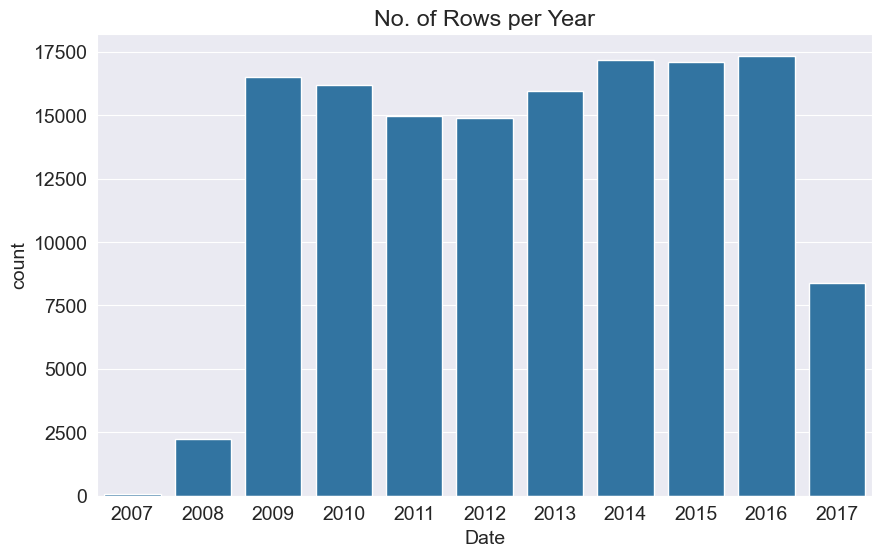

In [29]:
plt.title("No. of Rows per Year")
sns.countplot(x=pd.to_datetime(raw_df.Date).dt.year)

In [30]:
year = pd.to_datetime(raw_df.Date).dt.year

train_df = raw_df[year < 2015]
val_df = raw_df[year == 2015]
test_df = raw_df[year >2015]

print("train_df.shape: ", train_df.shape)
print("val_df.shape: ", val_df.shape)
print("test_df.shape: ", test_df.shape)

train_df.shape:  (97988, 23)
val_df.shape:  (17089, 23)
test_df.shape:  (25710, 23)


In [32]:
input_cols = list(train_df.columns) [1:-1]
target_col = "RainTomorrow"

In [33]:
print(input_cols)

['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday']


In [34]:
target_col

'RainTomorrow'